# Proyecto en dataset de ventas
Este proyecto tiene la misión de analizar las ventas del dataset descargado a partir de https://www.kaggle.com/datasets/rohitsahoo/sales-forecasting.   
El analisis está enfocado en el descubrimiento de tendencias, patrones que puedan ser de beneficio para la toma de decisiones de la superstore.

## 1. Importaciones

Primero agregar raíz del proyecto para que funcione la búsqueda de funciones en otras carpetas. Primero con Path("..") va una ruta hacia atrás, con resolve toma esa ruta y la hace completa, no solo relativa (hace la ruta completa del sistema), luego agrega esa ruta en los sys.path si es que ya no está y la agrega al principio.

In [1]:
import sys
from pathlib import Path
root = str(Path("..").resolve())
if root not in sys.path:
    sys.path.insert(0, root)

Luego si hacer todas las importaciones necesarias

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
%matplotlib inline

## 2. Carga de los datos

In [4]:
# Sube 1 nivel desde el notebook y luego va a lo siguiente de la ruta
ruta = r'..\data\raw\train.csv'
df = pd.read_csv(ruta)

## 3. Ver información inicial de los datos

In [5]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

In [7]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


## 4. Limpieza de datos y transformaciones


### 4.1 Nulls

Veamos si Postal Code tiene demasiados códigos postales diferentes. Veremos que tiene 626 así que de momento lo dejaremos.

In [8]:
df['Postal Code'].nunique()

626

### 4.2 Format

Los features de fechas son str así que lo cambiaremos a datetime.

In [9]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')
df['Ship Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')

### 4.3 Drops

Los ID's difícilmente van a proporcionarnos información valiosa, asi que los quitaremos.

In [10]:
df = df.drop(columns=['Row ID', 'Order ID', 'Customer ID', 'Product ID'])

El nombre del producto es una serie con demasiadas categorías, por lo que dificilmente pueda indicarnos algo valioso en las ventas.

In [11]:
df = df.drop(columns=['Product Name'])

El código postal probablemente venga condicionado por country, city y state, asi que veremos si vale la pena eliminarlo por redundancia.

In [12]:
df.groupby(['Country', 'City', 'State'])['Postal Code'].nunique()

Country        City         State       
United States  Aberdeen     South Dakota    1
               Abilene      Texas           1
               Akron        Ohio            1
               Albuquerque  New Mexico      1
               Alexandria   Virginia        1
                                           ..
               Woonsocket   Rhode Island    1
               Yonkers      New York        1
               York         Pennsylvania    1
               Yucaipa      California      1
               Yuma         Arizona         1
Name: Postal Code, Length: 600, dtype: int64

In [13]:
df.groupby(['Country', 'City', 'State'])['Postal Code'].nunique().describe()

count    600.000000
mean       1.045000
std        0.364962
min        0.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        6.000000
Name: Postal Code, dtype: float64

Al menos el 75% de las combinaciónes de Country, City y State tienen solo 1 Postal Code, asi que si viene condicionado, por lo que lo eliminamos.

In [14]:
df = df.drop(columns=['Postal Code'])

El nombre del cliente también dificilmente tiene alguna relación con el target, además, tenemos muchas categorías diferentes como para identificar tendencia.

In [15]:
df['Customer Name'].nunique()

793

In [16]:
df.drop(columns=['Customer Name'], inplace=True)

### 4.4 Fechas

Primero ordenamos los registros por 'Order Date'

In [17]:
df = df.sort_values(by='Order Date').reset_index()

In [18]:
df.drop(columns=['index'], inplace=True)

Colocamos la columna Order Date como el índice, para poder hacer operaciones de tiempo.

In [19]:
df = df.set_index(df['Order Date'])

In [20]:
df.drop(columns=['Order Date'], inplace=True)

## 5. Visualizations

In [21]:
df.head(2)

,Ship Date,Ship Mode,Segment,Country,City,State,Region,Category,Sub-Category,Sales
Order Date,,,,,,,,,,
2015-01-03,2015-01-03,Standard Class,Consumer,United States,Houston,Texas,Central,Office Supplies,Paper,16.448
2015-01-04,2015-01-04,Standard Class,Home Office,United States,Naperville,Illinois,Central,Office Supplies,Binders,3.540


### 5.1 General info

Totales de ventas cada mes a través del tiempo

Text(0.5, 1.0, 'Total sales by month')

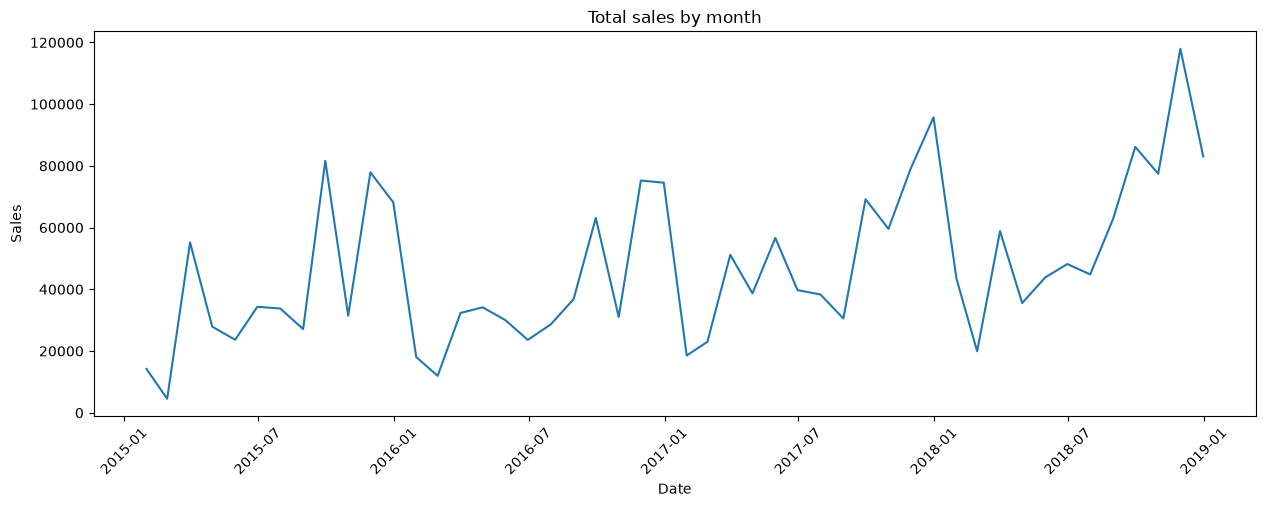

In [22]:
# Se samplean las ventas por ME (mes) del índice
plt.figure(figsize=(15, 5))

plt.plot(
    df['Sales'].resample('ME').sum()
)

plt.xticks(rotation=45)
plt.xlabel('Date')
plt.ylabel('Sales')
plt.title('Total sales by month')

Veremos como los datos están completamente sesgados, con casi todas las ventas por debajo de los 1,000

Text(0.5, 1.0, 'Sales distribution')

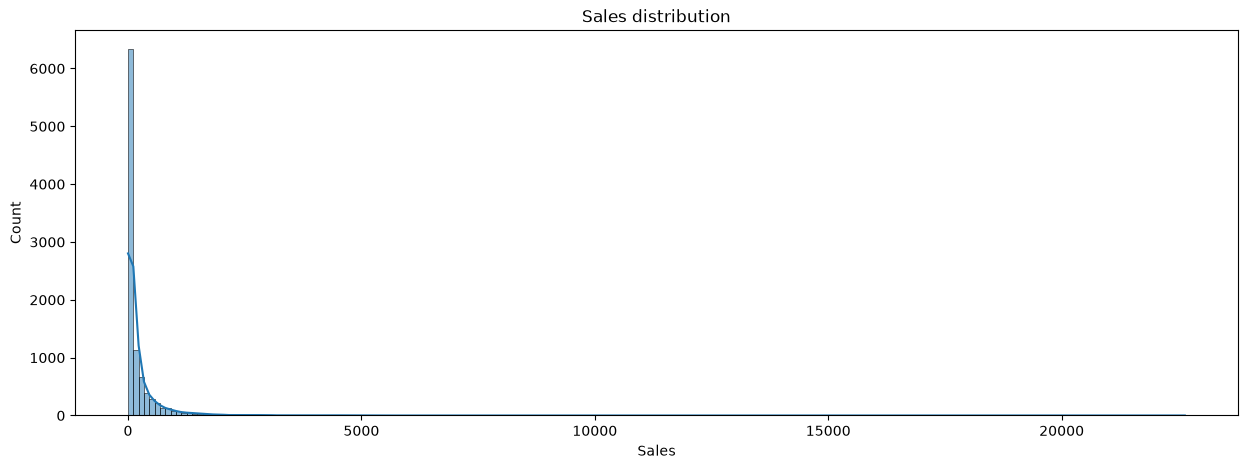

In [23]:
plt.figure(figsize=(15, 5))

sns.histplot(
    data=df,
    x='Sales',
    kde=True
)

plt.title('Sales distribution')

Como los datos están completamente sesgados, aplicaremos funciónes logaritmicas al target. Para mejor interpretación de tendencias.

De todas formas mantendremos el dataset original y otro con los datos con logaritmo.

In [24]:
df_log = df.copy()
df_log['Sales'] = np.log1p(df_log['Sales'])

### 5.2 Sales by different features

#### 5.2.1 Ship Mode

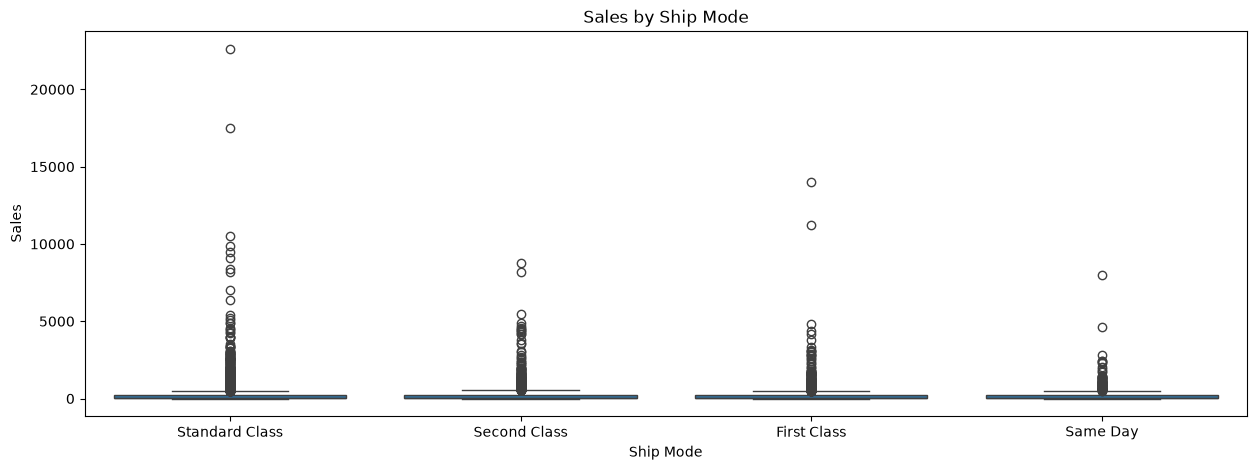

In [25]:
plt.figure(figsize=(15, 5))

sns.boxplot(
    data=df,
    x='Ship Mode',
    y='Sales'
)

plt.title('Sales by Ship Mode')

plt.show()

Distribución de Sales por Ship Mode.

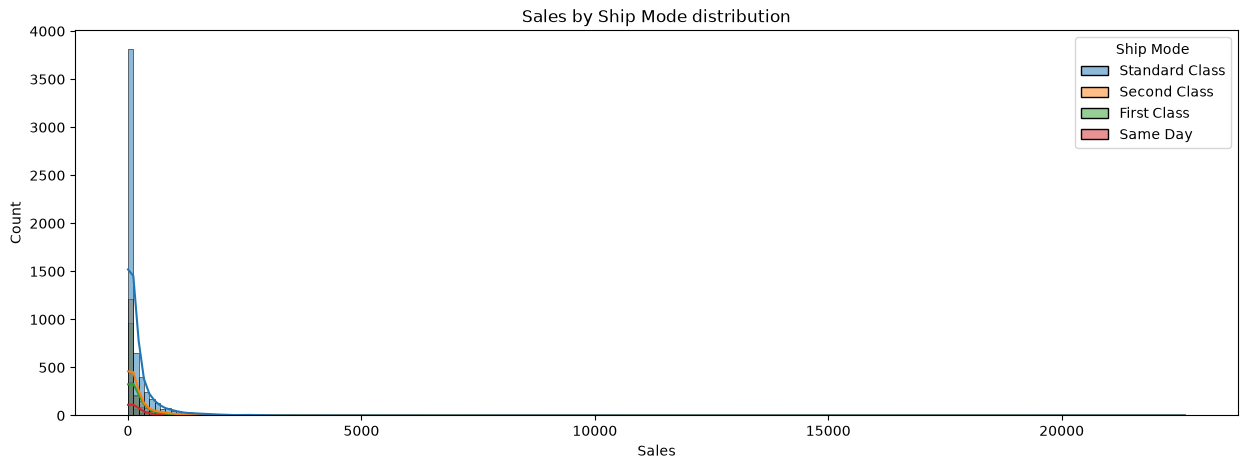

In [26]:
plt.figure(figsize=(15, 5))

sns.histplot(
    data=df,
    x='Sales',
    hue='Ship Mode',
    kde=True
)

plt.title('Sales by Ship Mode distribution')

plt.show()

Aplicamos los mismos gráficos anteriores de Ship Mode para nuestro dataset logarítmico.

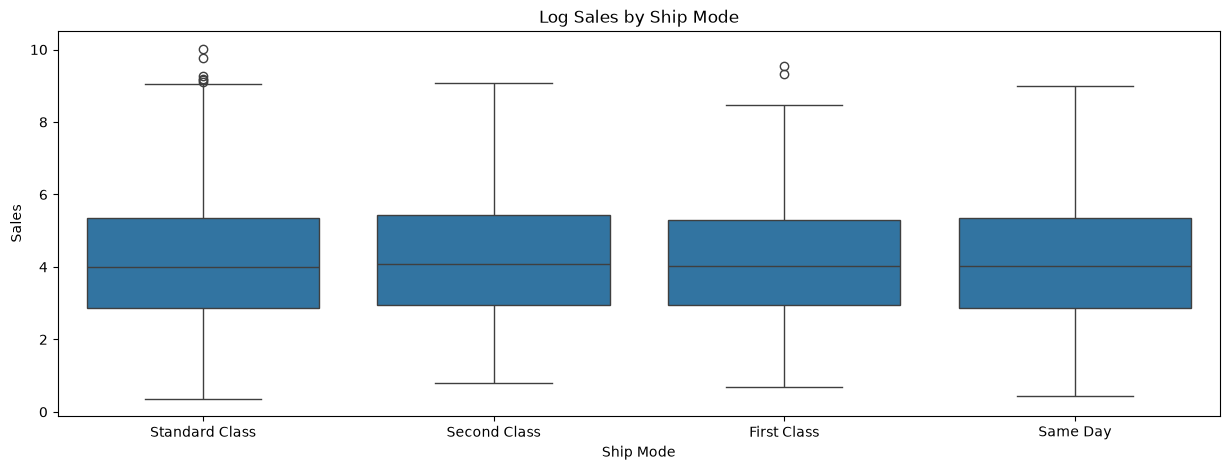

In [27]:
plt.figure(figsize=(15, 5))

sns.boxplot(
    data=df_log,
    x='Ship Mode',
    y='Sales'
)

plt.title('Log Sales by Ship Mode')

plt.show()

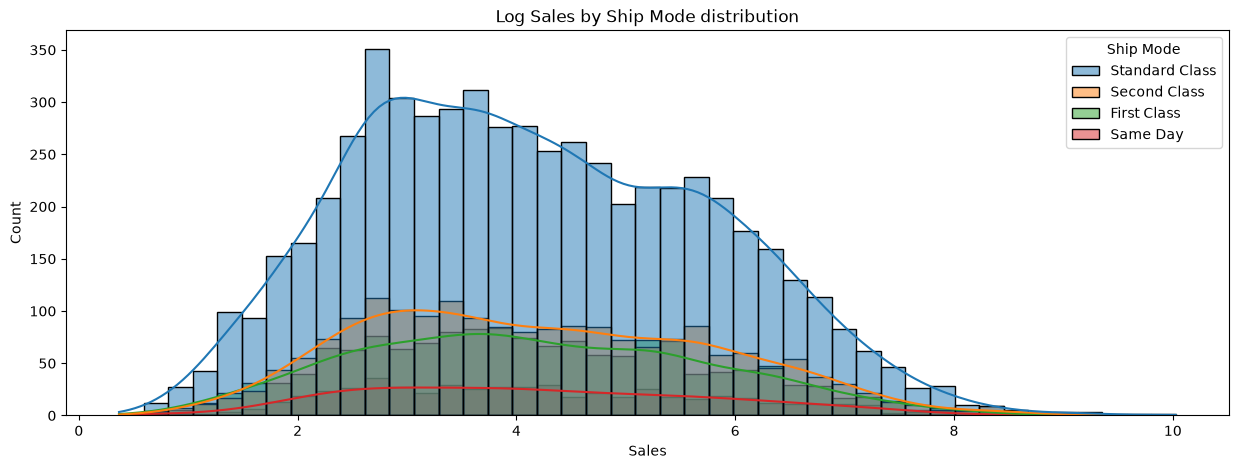

In [28]:
plt.figure(figsize=(15, 5))

sns.histplot(
    data=df_log,
    x='Sales',
    hue='Ship Mode',
    kde=True
)

plt.title('Log Sales by Ship Mode distribution')

plt.show()

#### 5.2.2 Segment

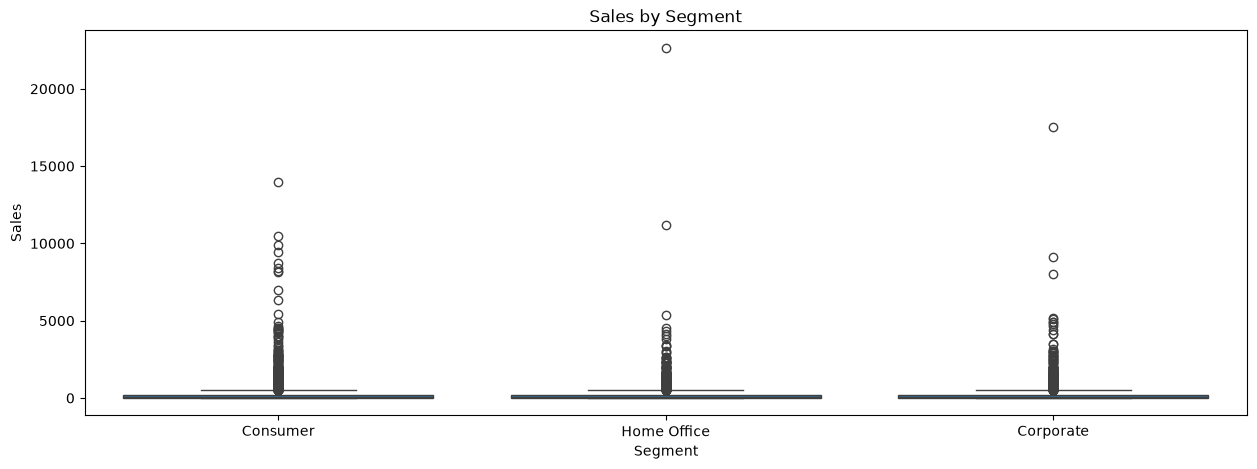

In [29]:
plt.figure(figsize=(15, 5))

sns.boxplot(
    data=df,
    x='Segment',
    y='Sales'
)

plt.title('Sales by Segment')

plt.show()

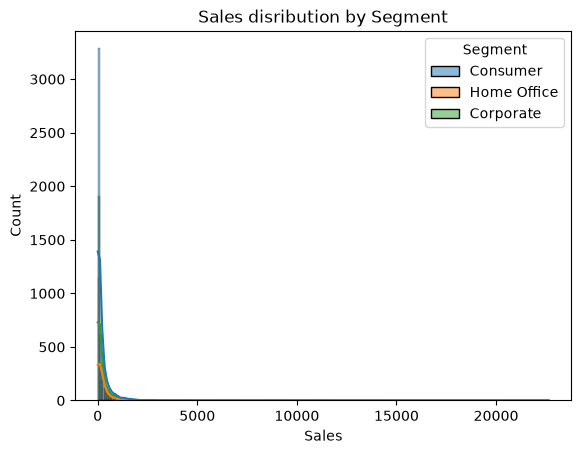

In [30]:
sns.histplot(
    data=df,
    x='Sales',
    hue='Segment',
    kde=True
)

plt.title('Sales disribution by Segment')

plt.show()

Aplicamos misma lógica anterior de Segment para nuestro DataFrame logarítmico.

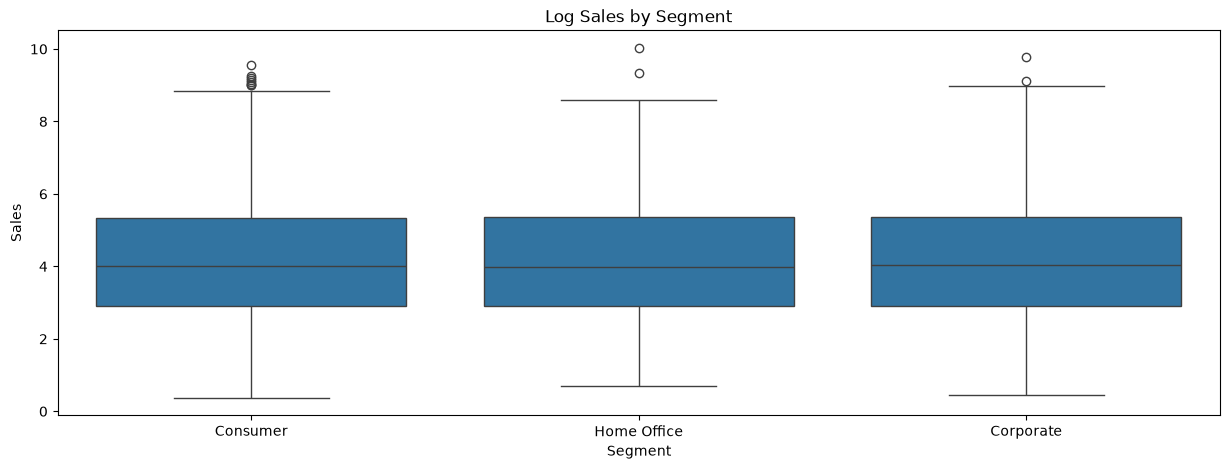

In [31]:
plt.figure(figsize=(15, 5))

sns.boxplot(
    data=df_log,
    x='Segment',
    y='Sales'
)

plt.title('Log Sales by Segment')

plt.show()

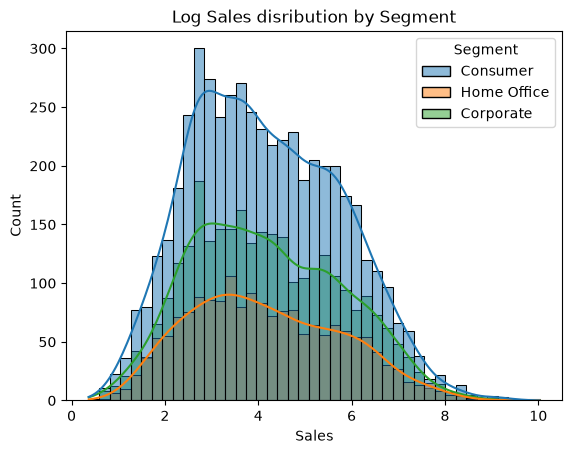

In [32]:
sns.histplot(
    data=df_log,
    x='Sales',
    hue='Segment',
    kde=True
)

plt.title('Log Sales disribution by Segment')

plt.show()

#### 5.2.3 Country

Todas las ventas fueron hechas solo en estados unidos.

Text(0.5, 1.0, 'Sales by country')

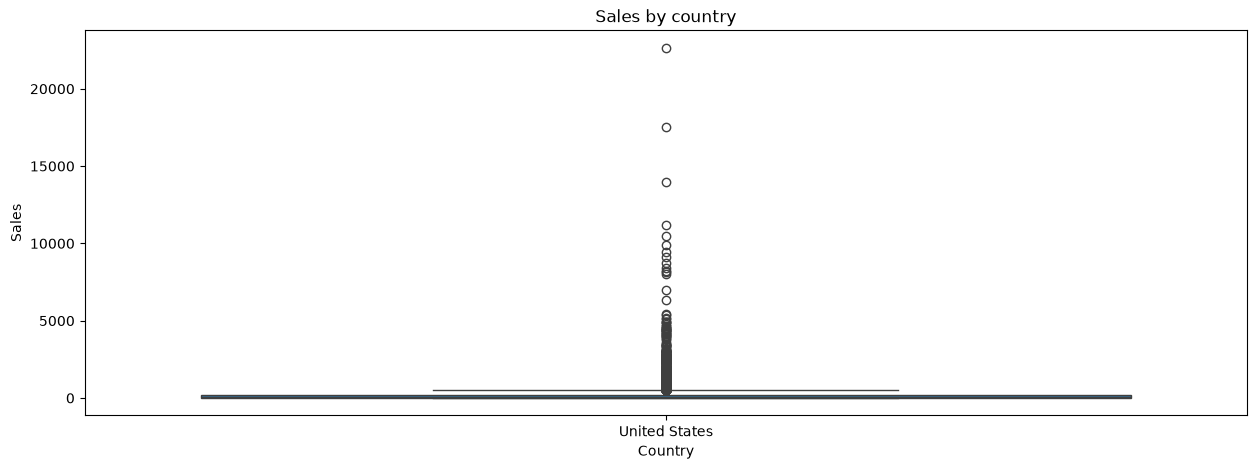

In [33]:
plt.figure(figsize=(15, 5))

sns.boxplot(
    data=df,
    x='Country',
    y='Sales'
)

plt.title('Sales by country')

#### 5.2.4 City

El feature city tiene muchas categorías posibles así que lo mejor que haremos en este caso es saber cuales son las que proporcionan mayores ganancias.

In [34]:
df['City'].nunique()

529

Boxplot completo

Text(0.5, 1.0, 'Sales by City')

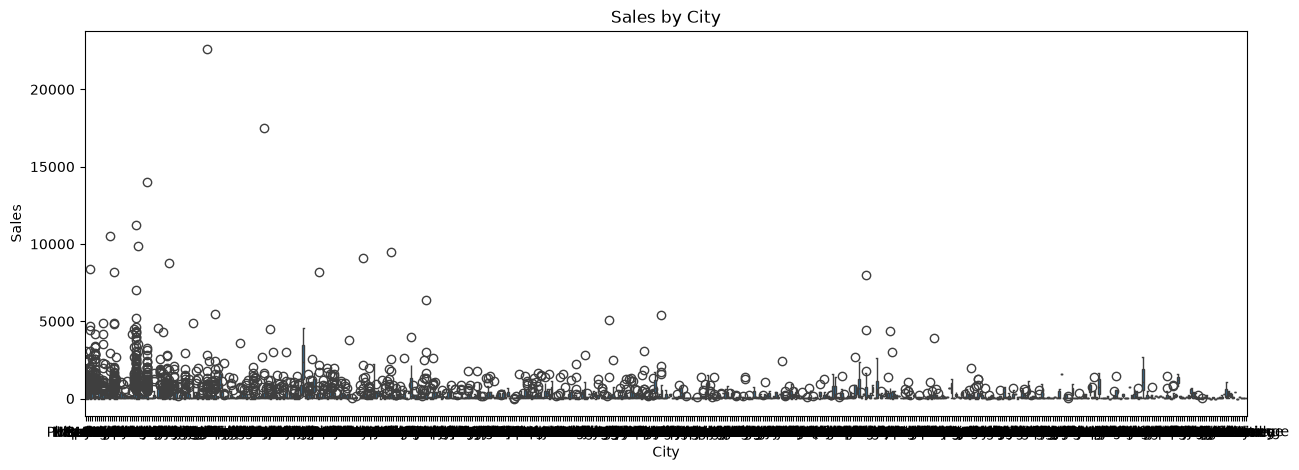

In [35]:
plt.figure(figsize=(15, 5))

sns.boxplot(
    data=df,
    x='City',
    y='Sales'
)

plt.title('Sales by City')

Agrupar por city (top 10 promedio de ventas)

In [36]:
df.head()

,Ship Date,Ship Mode,Segment,Country,City,State,Region,Category,Sub-Category,Sales
Order Date,,,,,,,,,,
2015-01-03,2015-01-03,Standard Class,Consumer,United States,Houston,Texas,Central,Office Supplies,Paper,16.448
2015-01-04,2015-01-04,Standard Class,Home Office,United States,Naperville,Illinois,Central,Office Supplies,Binders,3.540
2015-01-04,2015-01-04,Standard Class,Home Office,United States,Naperville,Illinois,Central,Office Supplies,Storage,272.736
2015-01-04,2015-01-04,Standard Class,Home Office,United States,Naperville,Illinois,Central,Office Supplies,Labels,11.784
2015-01-05,2015-01-05,Standard Class,Consumer,United States,Philadelphia,Pennsylvania,East,Office Supplies,Art,19.536


In [37]:
group_city_top_10_sales = df.groupby('City')['Sales'].mean().sort_values(ascending=False).head(10)
names_top_10_cities = group_city_top_10_sales.index
names_top_10_cities

Index(['Jamestown', 'Cheyenne', 'Bellingham', 'Independence', 'Burbank',
       'Buffalo', 'Burlington', 'Beverly', 'Lafayette', 'Sparks'],
      dtype='str', name='City')

Obtener solo los registros en donde City esté dentro del top.

In [38]:
df_top10_city = df[df['City'].isin(names_top_10_cities)]

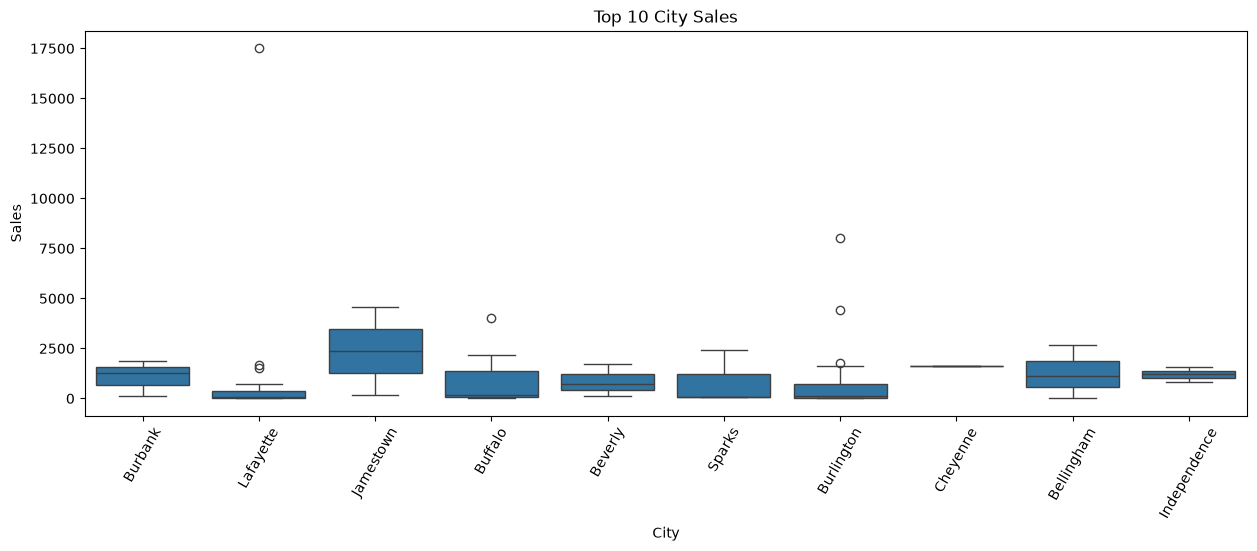

In [39]:
plt.figure(figsize=(15, 5))

sns.boxplot(
    data=df_top10_city,
    x='City',
    y='Sales'
)

plt.title('Top 10 City Sales')

plt.xticks(rotation=60)
plt.show()

Veamos el top 10 en los registros logarítmicos

In [40]:
df_top10_city_log = df_log[df_log['City'].isin(names_top_10_cities)]

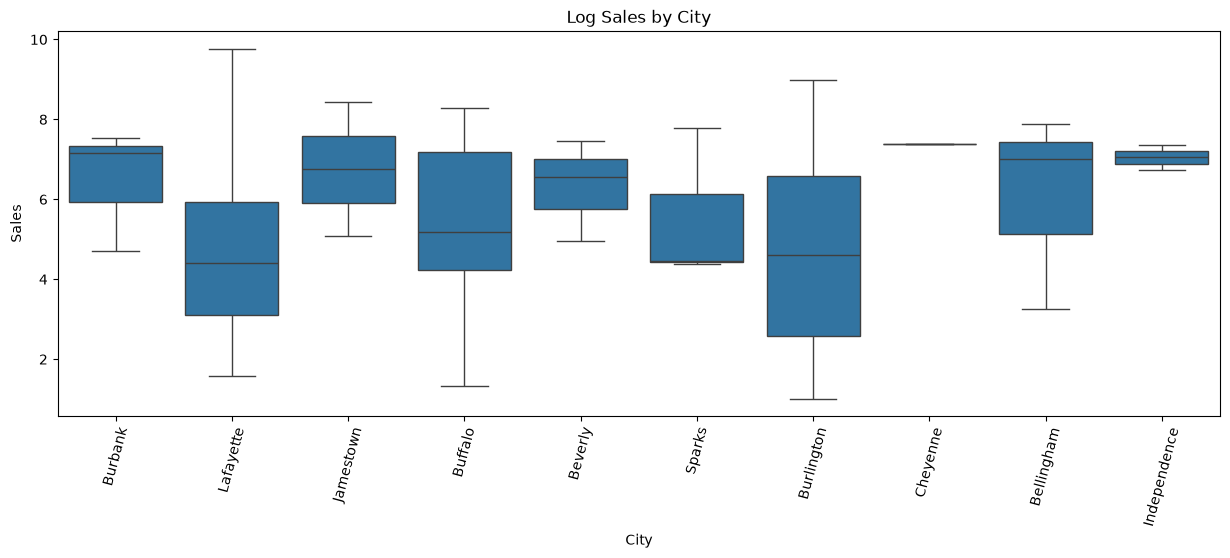

In [41]:
plt.figure(figsize=(15, 5))

sns.boxplot(
    data=df_top10_city_log,
    x='City',
    y='Sales'
)

plt.title('Log Sales by City')

plt.xticks(rotation=75)

plt.show()

Distribución de ventas por City en DataFrame logarítmico.

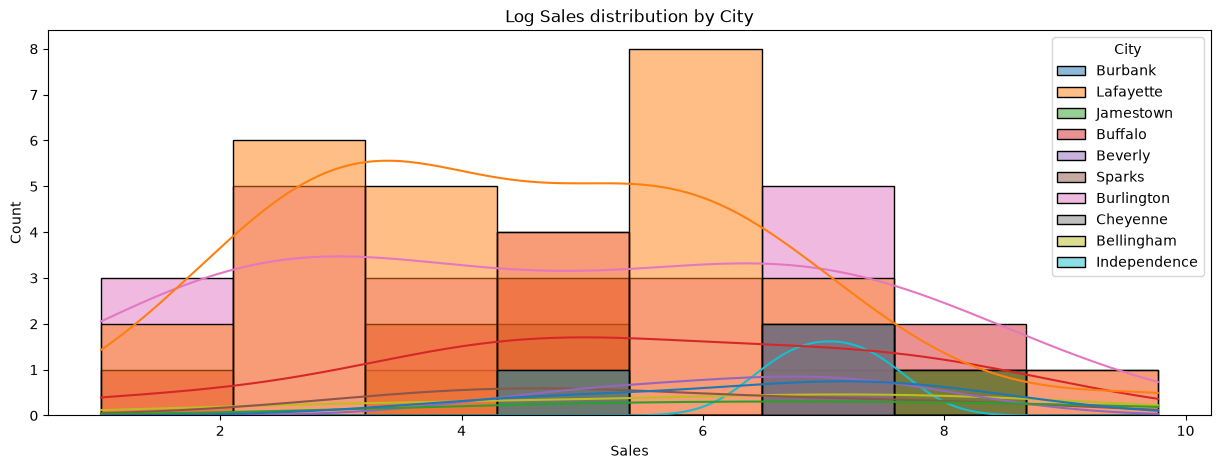

In [42]:
plt.figure(figsize=(15, 5))

sns.histplot(
    data=df_top10_city_log,
    x='Sales',
    kde=True,
    hue='City'
)

plt.title('Log Sales distribution by City')

plt.show()

#### 5.2.5 State

Aqui hay demasiados State's así que luego solo obtendremos los que mejores ganancias dan.

Text(0.5, 1.0, 'Sales by State')

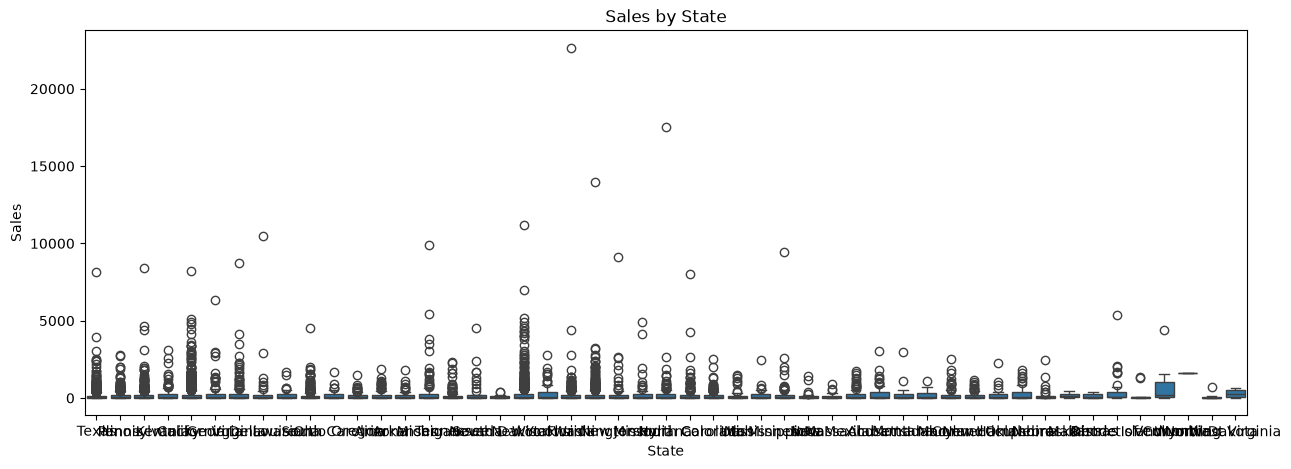

In [43]:
plt.figure(figsize=(15, 5))

sns.boxplot(
    data=df,
    x='State',
    y='Sales'
)

plt.title('Sales by State')

Agrupar por State (top 10 promedio de ventas)

In [44]:
df.head()

,Ship Date,Ship Mode,Segment,Country,City,State,Region,Category,Sub-Category,Sales
Order Date,,,,,,,,,,
2015-01-03,2015-01-03,Standard Class,Consumer,United States,Houston,Texas,Central,Office Supplies,Paper,16.448
2015-01-04,2015-01-04,Standard Class,Home Office,United States,Naperville,Illinois,Central,Office Supplies,Binders,3.540
2015-01-04,2015-01-04,Standard Class,Home Office,United States,Naperville,Illinois,Central,Office Supplies,Storage,272.736
2015-01-04,2015-01-04,Standard Class,Home Office,United States,Naperville,Illinois,Central,Office Supplies,Labels,11.784
2015-01-05,2015-01-05,Standard Class,Consumer,United States,Philadelphia,Pennsylvania,East,Office Supplies,Art,19.536


In [45]:
group_state_top_10_sales = df.groupby('State')['Sales'].mean().sort_values(ascending=False).head(10)
names_top_10_states = group_state_top_10_sales.index
names_top_10_states

Index(['Wyoming', 'Vermont', 'Nevada', 'Rhode Island', 'Montana', 'Indiana',
       'Missouri', 'Minnesota', 'Alabama', 'Virginia'],
      dtype='str', name='State')

Obtener solo los registros en donde State esté dentro del top.

In [46]:
df_top10_state = df[df['State'].isin(names_top_10_states)]

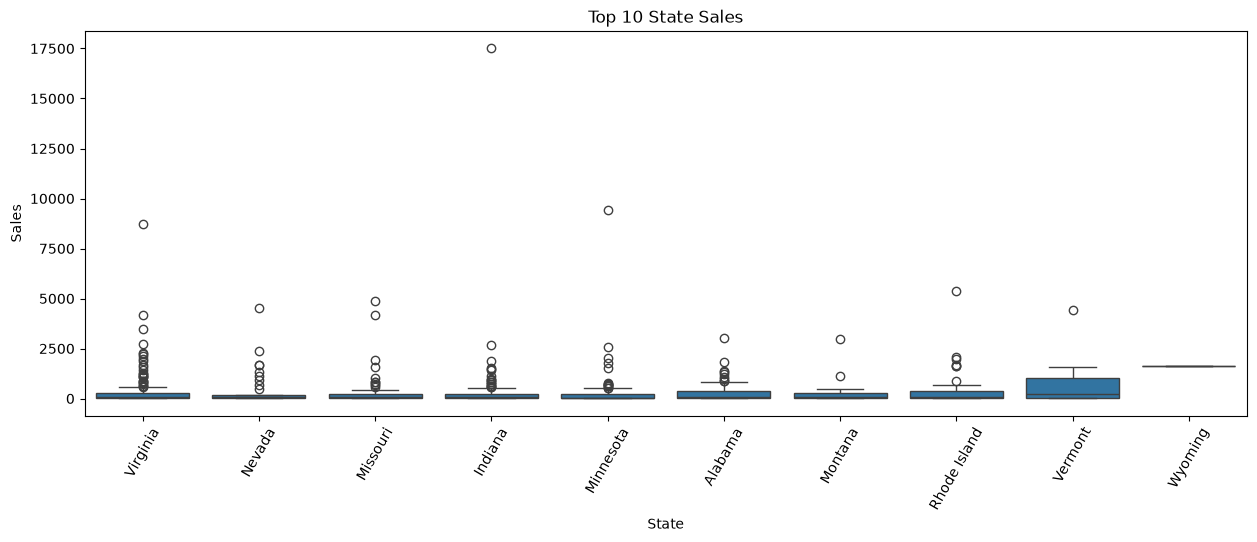

In [47]:
plt.figure(figsize=(15, 5))

sns.boxplot(
    data=df_top10_state,
    x='State',
    y='Sales'
)

plt.title('Top 10 State Sales')

plt.xticks(rotation=60)
plt.show()

Aplicar lógica para DataFrame logarítmico.

In [48]:
df_top10_state_log = df_log[df_log['State'].isin(names_top_10_states)]

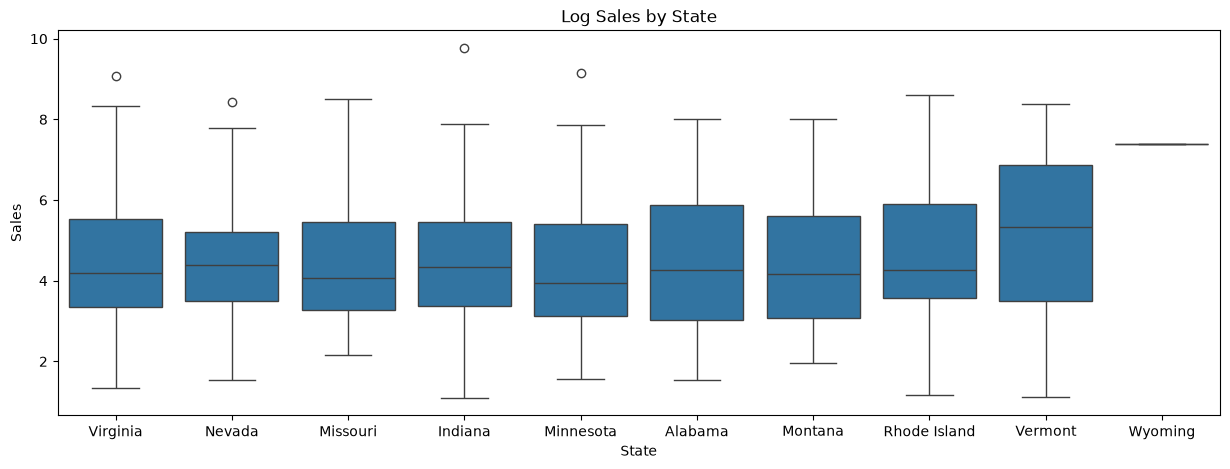

In [49]:
plt.figure(figsize=(15, 5))

sns.boxplot(
    data=df_top10_state_log,
    x='State',
    y='Sales'
)

plt.title('Log Sales by State')

plt.show()

#### 5.2.6 Sales by Region

In [50]:
df.head()

,Ship Date,Ship Mode,Segment,Country,City,State,Region,Category,Sub-Category,Sales
Order Date,,,,,,,,,,
2015-01-03,2015-01-03,Standard Class,Consumer,United States,Houston,Texas,Central,Office Supplies,Paper,16.448
2015-01-04,2015-01-04,Standard Class,Home Office,United States,Naperville,Illinois,Central,Office Supplies,Binders,3.540
2015-01-04,2015-01-04,Standard Class,Home Office,United States,Naperville,Illinois,Central,Office Supplies,Storage,272.736
2015-01-04,2015-01-04,Standard Class,Home Office,United States,Naperville,Illinois,Central,Office Supplies,Labels,11.784
2015-01-05,2015-01-05,Standard Class,Consumer,United States,Philadelphia,Pennsylvania,East,Office Supplies,Art,19.536


BoxPlot comparando las 4 regiones disponibles.

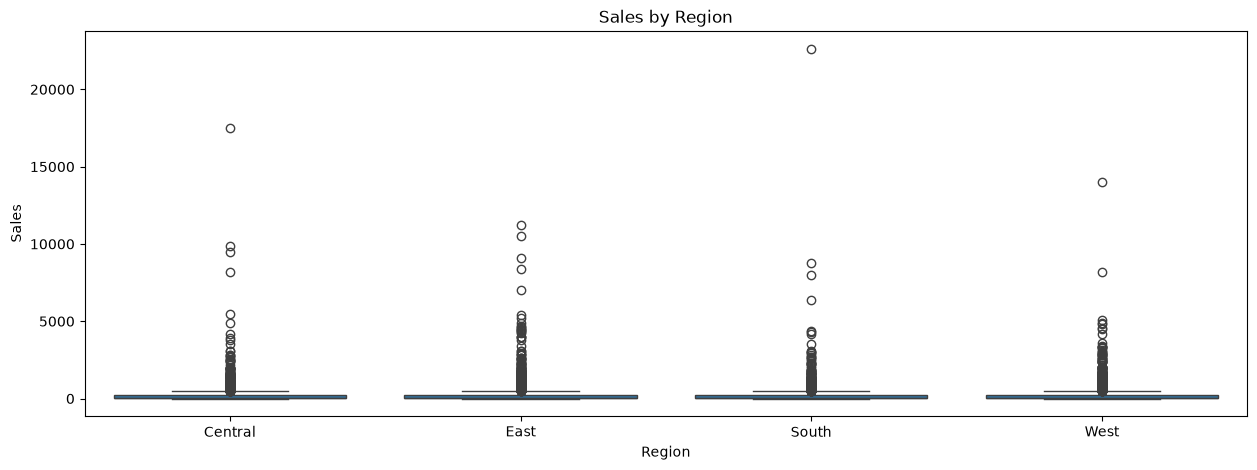

In [51]:
plt.figure(figsize=(15, 5))

sns.boxplot(
    data=df,
    x='Region',
    y='Sales'
)
plt.title('Sales by Region')

plt.show()

Distribución de las ventas por Region

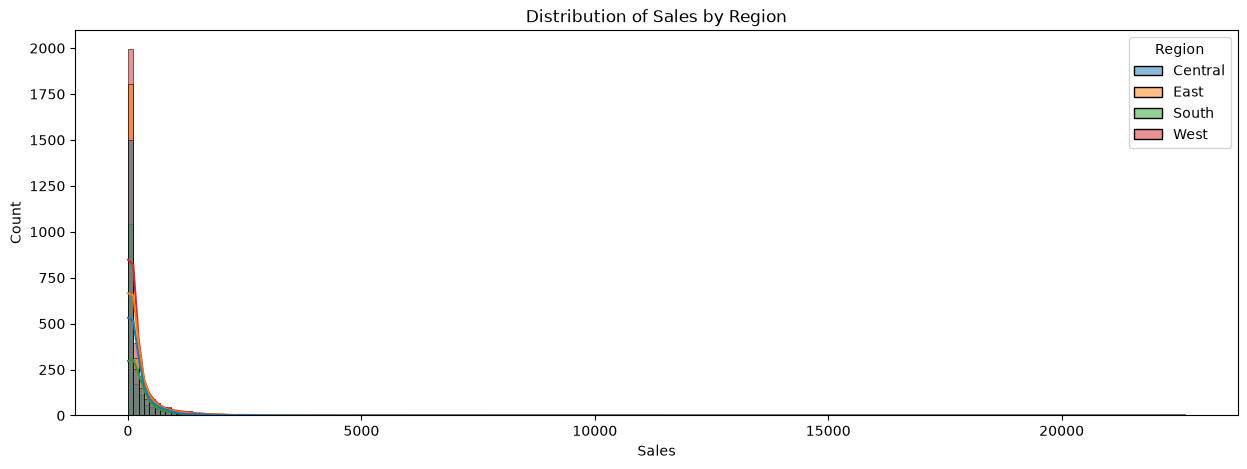

In [52]:
plt.figure(figsize=(15, 5))

sns.histplot(
    data=df,
    x='Sales',
    kde=True,
    hue='Region'
)
plt.title('Distribution of Sales by Region')

plt.show()

Aplicar misma lógica para DataFrame logarítmico.

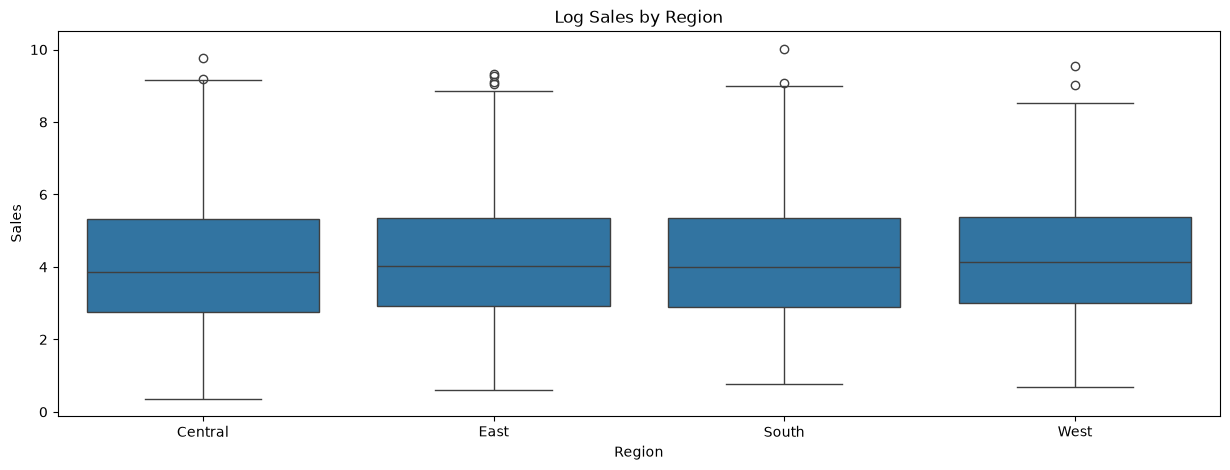

In [53]:
plt.figure(figsize=(15, 5))

sns.boxplot(
    data=df_log,
    x='Region',
    y='Sales'
)
plt.title('Log Sales by Region')

plt.show()

Distribución de las ventas log por Region

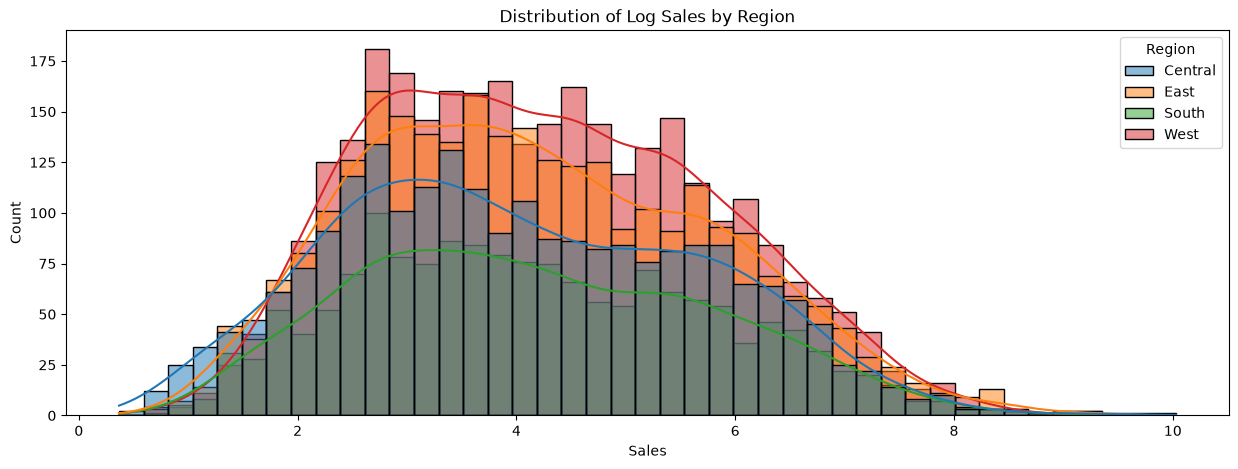

In [54]:
plt.figure(figsize=(15, 5))

sns.histplot(
    data=df_log,
    x='Sales',
    kde=True,
    hue='Region'
)
plt.title('Distribution of Log Sales by Region')

plt.show()

#### 5.2.7 Sales by category

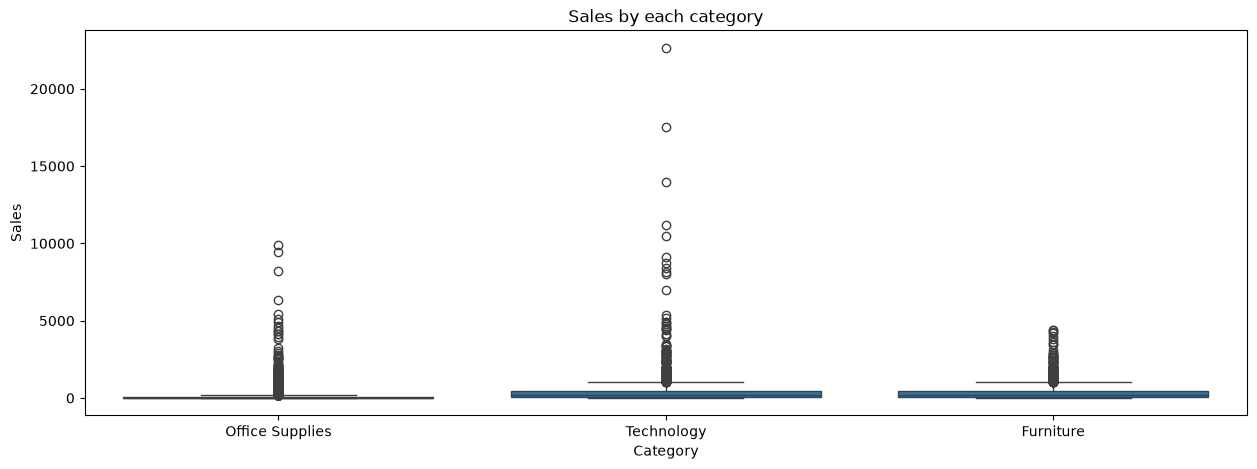

In [55]:
plt.figure(figsize=(15, 5))

sns.boxplot(
    data=df,
    x='Category',
    y='Sales'
)

plt.title('Sales by each category')

plt.show()

Distribución de las ventas por Category

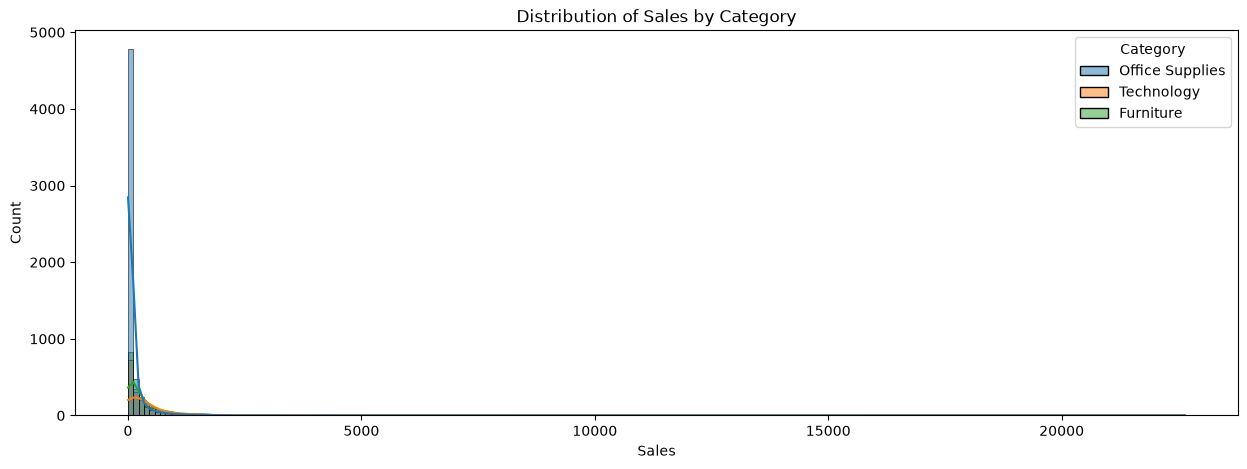

In [56]:
plt.figure(figsize=(15, 5))

sns.histplot(
    data=df,
    x='Sales',
    kde=True,
    hue='Category'
)
plt.title('Distribution of Sales by Category')

plt.show()

Aplicar lógica para log DataFrame

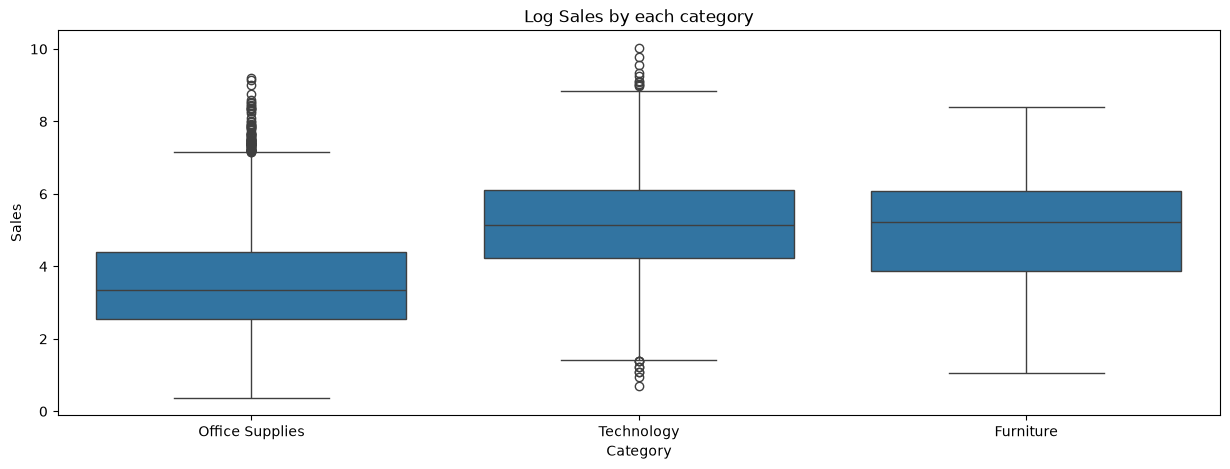

In [57]:
plt.figure(figsize=(15, 5))

sns.boxplot(
    data=df_log,
    x='Category',
    y='Sales'
)

plt.title('Log Sales by each category')

plt.show()

Distribución de las log ventas por Category

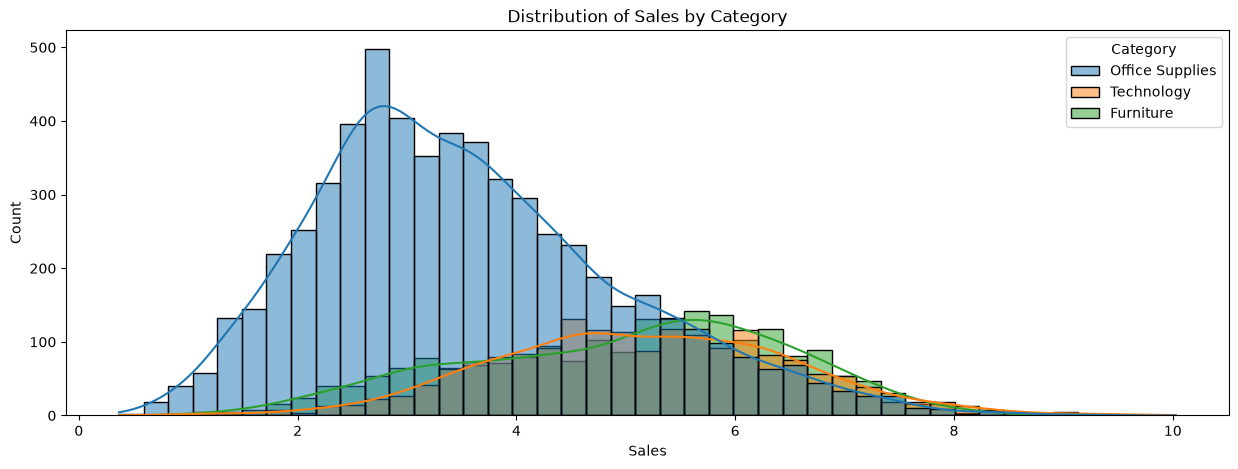

In [58]:
plt.figure(figsize=(15, 5))

sns.histplot(
    data=df_log,
    x='Sales',
    kde=True,
    hue='Category'
)
plt.title('Distribution of Sales by Category')

plt.show()

#### 5.2.8 Sales by sub-category

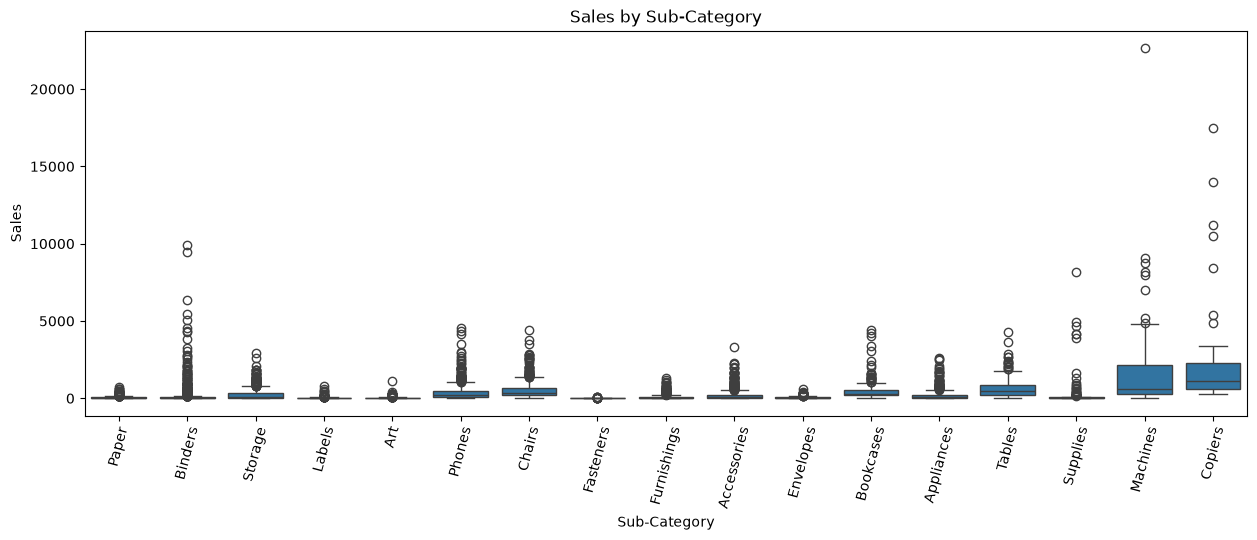

In [59]:
plt.figure(figsize=(15, 5))

sns.boxplot(
    data=df,
    x='Sub-Category',
    y='Sales'
)

plt.title('Sales by Sub-Category')

plt.xticks(rotation=75)

plt.show()

Log Sales by Sub-Category

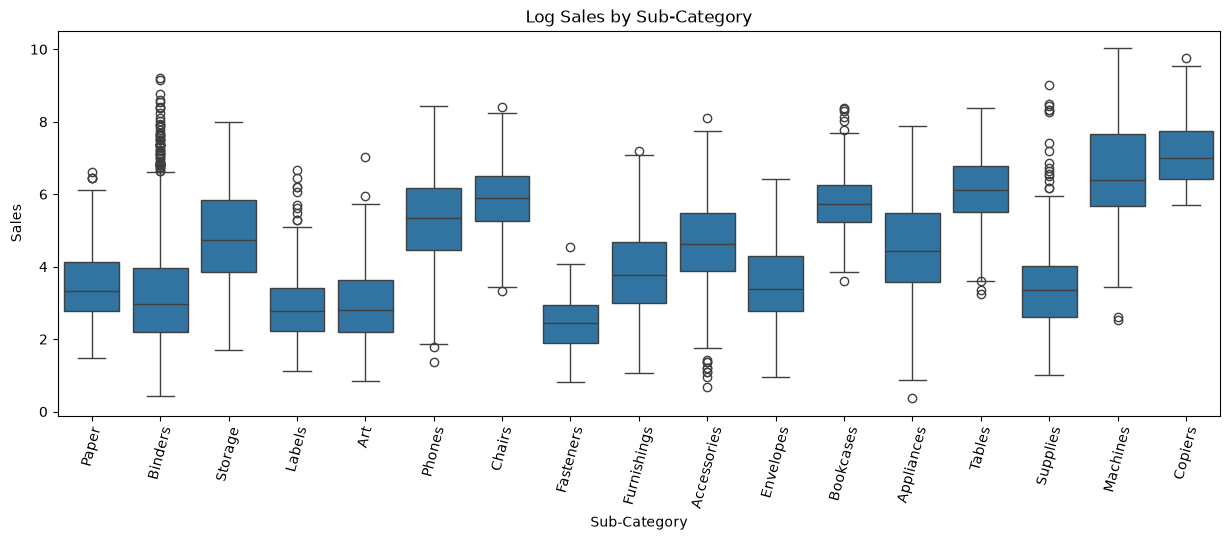

In [60]:
plt.figure(figsize=(15, 5))

sns.boxplot(
    data=df_log,
    x='Sub-Category',
    y='Sales'
)

plt.title('Log Sales by Sub-Category')

plt.xticks(rotation=75)

plt.show()

### 5.3 Mean and Sum

In [61]:
df.head()

,Ship Date,Ship Mode,Segment,Country,City,State,Region,Category,Sub-Category,Sales
Order Date,,,,,,,,,,
2015-01-03,2015-01-03,Standard Class,Consumer,United States,Houston,Texas,Central,Office Supplies,Paper,16.448
2015-01-04,2015-01-04,Standard Class,Home Office,United States,Naperville,Illinois,Central,Office Supplies,Binders,3.540
2015-01-04,2015-01-04,Standard Class,Home Office,United States,Naperville,Illinois,Central,Office Supplies,Storage,272.736
2015-01-04,2015-01-04,Standard Class,Home Office,United States,Naperville,Illinois,Central,Office Supplies,Labels,11.784
2015-01-05,2015-01-05,Standard Class,Consumer,United States,Philadelphia,Pennsylvania,East,Office Supplies,Art,19.536


#### 5.3.1. Ship Mode

Agrupamos por categoría de Ship Mode y vemos el promedio y la suma de las ventas en cada uno.

In [62]:
group_shipmode_sales_stats = df.groupby('Ship Mode')['Sales'].agg(['mean', 'sum'])

In [63]:
group_shipmode_sales_stats

,mean,sum
Ship Mode,,
First Class,230.228020,3.455723e+05
Same Day,232.749143,1.252190e+05
Second Class,236.547939,4.499142e+05
Standard Class,228.849856,1.340831e+06


Generar figure con barras para mean y sum.

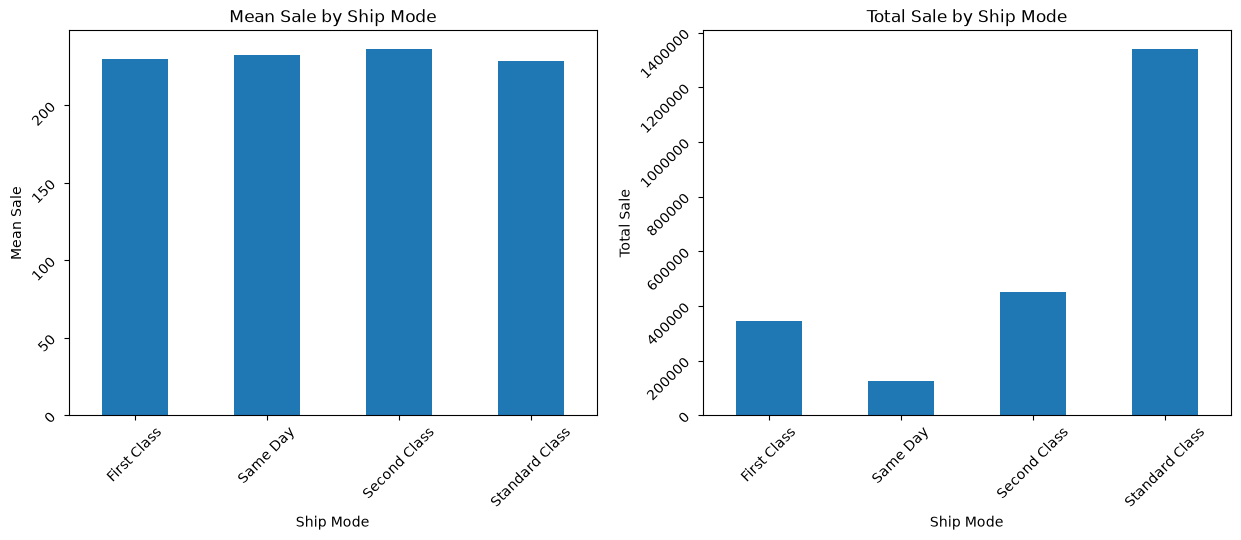

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Grafico 1: mean
group_shipmode_sales_stats['mean'].plot(
    kind='bar',
    ax=axes[0]
)
axes[0].set_title('Mean Sale by Ship Mode')
axes[0].set_xlabel('Ship Mode')
axes[0].set_ylabel('Mean Sale')
axes[0].tick_params(rotation=45)


# Grafico 2: sum
group_shipmode_sales_stats['sum'].plot(
    kind='bar',
    ax=axes[1]
)
axes[1].set_title('Total Sale by Ship Mode')
axes[1].set_xlabel('Ship Mode')
axes[1].set_ylabel('Total Sale')
axes[1].tick_params(rotation=45)
axes[1].ticklabel_format(style='plain', axis='y')


plt.show()

#### 5.3.2 Segment

In [65]:
df.head()

,Ship Date,Ship Mode,Segment,Country,City,State,Region,Category,Sub-Category,Sales
Order Date,,,,,,,,,,
2015-01-03,2015-01-03,Standard Class,Consumer,United States,Houston,Texas,Central,Office Supplies,Paper,16.448
2015-01-04,2015-01-04,Standard Class,Home Office,United States,Naperville,Illinois,Central,Office Supplies,Binders,3.540
2015-01-04,2015-01-04,Standard Class,Home Office,United States,Naperville,Illinois,Central,Office Supplies,Storage,272.736
2015-01-04,2015-01-04,Standard Class,Home Office,United States,Naperville,Illinois,Central,Office Supplies,Labels,11.784
2015-01-05,2015-01-05,Standard Class,Consumer,United States,Philadelphia,Pennsylvania,East,Office Supplies,Art,19.536


Grupo de Segment con mean y sum.

In [66]:
group_segment_sales_stats = df.groupby('Segment')['Sales'].agg(['mean', 'sum'])
group_segment_sales_stats

,mean,sum
Segment,,
Consumer,225.065777,1.148061e+06
Corporate,233.150720,6.884941e+05
Home Office,243.403309,4.249822e+05


Plots de mean y sum

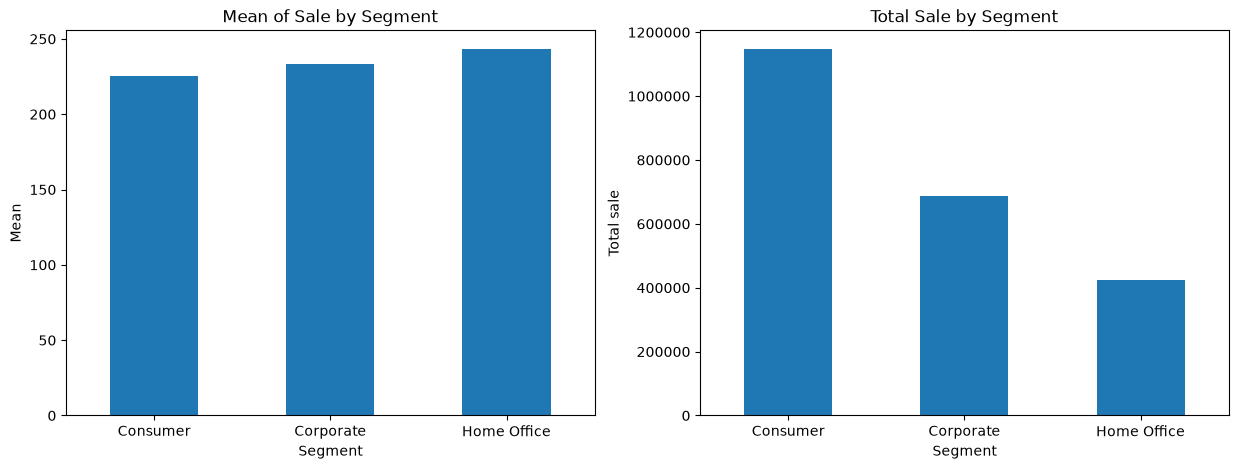

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: mean
group_segment_sales_stats['mean'].plot(
    kind='bar',
    ax=axes[0]
)
axes[0].set_title('Mean of Sale by Segment')
axes[0].set_xlabel('Segment')
axes[0].set_ylabel('Mean')
axes[0].tick_params(rotation=0)


# Gráfico 2: sum
group_segment_sales_stats['sum'].plot(
    kind='bar',
    ax=axes[1]
)
axes[1].set_title('Total Sale by Segment')
axes[1].set_xlabel('Segment')
axes[1].set_ylabel('Total sale')
axes[1].tick_params(rotation=0)
axes[1].ticklabel_format(style='plain', axis='y')

#### 5.3.3 City

In [68]:
df.head()

,Ship Date,Ship Mode,Segment,Country,City,State,Region,Category,Sub-Category,Sales
Order Date,,,,,,,,,,
2015-01-03,2015-01-03,Standard Class,Consumer,United States,Houston,Texas,Central,Office Supplies,Paper,16.448
2015-01-04,2015-01-04,Standard Class,Home Office,United States,Naperville,Illinois,Central,Office Supplies,Binders,3.540
2015-01-04,2015-01-04,Standard Class,Home Office,United States,Naperville,Illinois,Central,Office Supplies,Storage,272.736
2015-01-04,2015-01-04,Standard Class,Home Office,United States,Naperville,Illinois,Central,Office Supplies,Labels,11.784
2015-01-05,2015-01-05,Standard Class,Consumer,United States,Philadelphia,Pennsylvania,East,Office Supplies,Art,19.536


Grupo de City con mean y sum.

In [69]:
group_city_sales_stats = df.groupby('City')['Sales'].agg(['mean', 'sum'])
group_city_sales_stats

,mean,sum
City,,
Aberdeen,25.500000,25.500
Abilene,1.392000,1.392
Akron,136.212200,2724.244
Albuquerque,158.582857,2220.160
Alexandria,344.973125,5519.570
...,...,...
Woonsocket,48.887500,195.550
Yonkers,510.511067,7657.666
York,163.595600,817.978


En este caso al ser muchos, solo tomaremos los 10 que más ventas totales han entregado.

In [70]:
group_city_sales_stats = group_city_sales_stats.sort_values(by='sum', ascending=False).head(10)
group_city_sales_stats

,mean,sum
City,,
New York City,283.347415,252462.5470
Los Angeles,238.214534,173420.1810
Seattle,272.550052,116106.3220
San Francisco,218.082240,109041.1200
Philadelphia,204.589754,108841.7490
Houston,171.005729,63956.1428
Chicago,155.260172,47820.1330
San Diego,279.535465,47521.0290
Jacksonville,357.705464,44713.1830


Plots de mean y sum

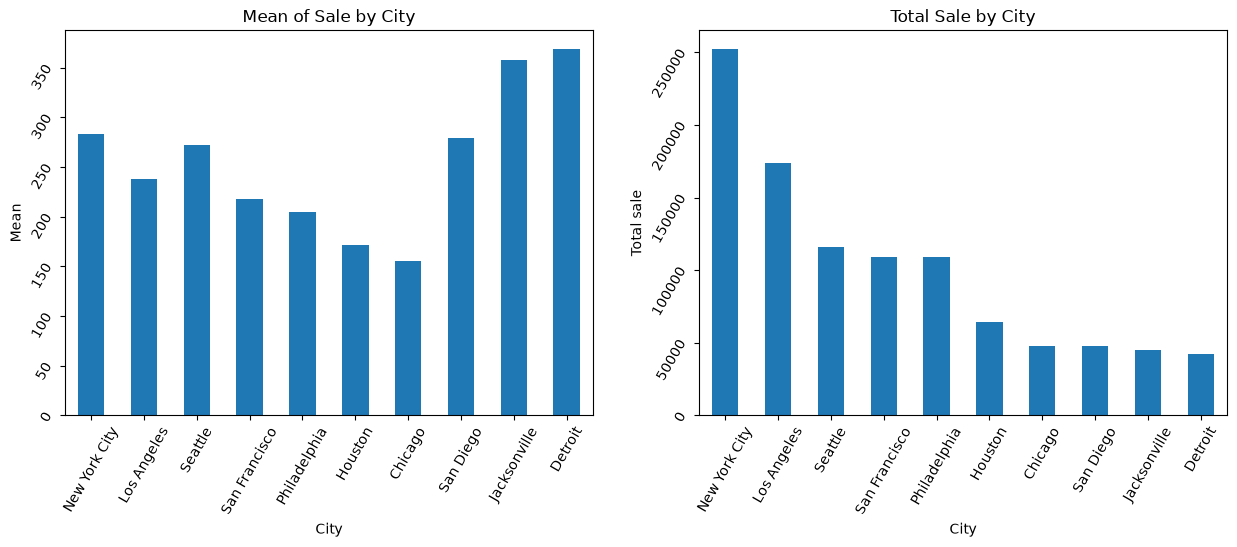

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: mean
group_city_sales_stats['mean'].plot(
    kind='bar',
    ax=axes[0]
)
axes[0].set_title('Mean of Sale by City')
axes[0].set_xlabel('City')
axes[0].set_ylabel('Mean')
axes[0].tick_params(rotation=60)


# Gráfico 2: sum
group_city_sales_stats['sum'].plot(
    kind='bar',
    ax=axes[1]
)
axes[1].set_title('Total Sale by City')
axes[1].set_xlabel('City')
axes[1].set_ylabel('Total sale')
axes[1].tick_params(rotation=60)
axes[1].ticklabel_format(style='plain', axis='y')

#### 5.3.4 State

In [72]:
df.head()

,Ship Date,Ship Mode,Segment,Country,City,State,Region,Category,Sub-Category,Sales
Order Date,,,,,,,,,,
2015-01-03,2015-01-03,Standard Class,Consumer,United States,Houston,Texas,Central,Office Supplies,Paper,16.448
2015-01-04,2015-01-04,Standard Class,Home Office,United States,Naperville,Illinois,Central,Office Supplies,Binders,3.540
2015-01-04,2015-01-04,Standard Class,Home Office,United States,Naperville,Illinois,Central,Office Supplies,Storage,272.736
2015-01-04,2015-01-04,Standard Class,Home Office,United States,Naperville,Illinois,Central,Office Supplies,Labels,11.784
2015-01-05,2015-01-05,Standard Class,Consumer,United States,Philadelphia,Pennsylvania,East,Office Supplies,Art,19.536


Grupo de State con mean y sum.

In [73]:
group_state_sales_stats = df.groupby('State')['Sales'].agg(['mean', 'sum'])
group_state_sales_stats

,mean,sum
State,,
Alabama,319.846557,19510.6400
Arizona,158.173350,35272.6570
Arkansas,194.635500,11678.1300
California,229.345562,446306.4635
Colorado,177.886022,31841.5980
Connecticut,163.223866,13384.3570
Delaware,293.795688,27322.9990
District of Columbia,286.502000,2865.0200
Florida,237.095260,88436.5320


Obtener el top 10 de los State que más han aportado.

In [74]:
group_state_sales_stats = group_state_sales_stats.sort_values(by='sum', ascending=False).head(10)
group_state_sales_stats

,mean,sum
State,,
California,229.345562,446306.4635
New York,279.271784,306361.1470
Texas,173.250290,168572.5322
Washington,268.267560,135206.8500
Pennsylvania,199.788058,116276.6500
Florida,237.095260,88436.5320
Illinois,164.050760,79236.5170
Michigan,300.933099,76136.0740
Ohio,165.485352,75130.3500


Plots de mean y sum

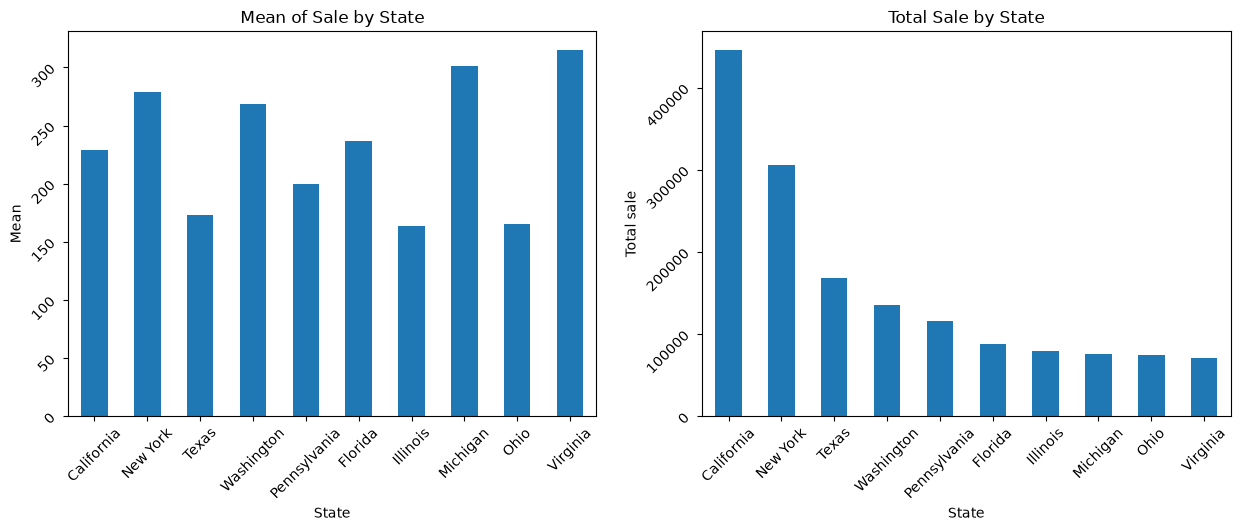

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: mean
group_state_sales_stats['mean'].plot(
    kind='bar',
    ax=axes[0]
)
axes[0].set_title('Mean of Sale by State')
axes[0].set_xlabel('State')
axes[0].set_ylabel('Mean')
axes[0].tick_params(rotation=45)


# Gráfico 2: sum
group_state_sales_stats['sum'].plot(
    kind='bar',
    ax=axes[1]
)
axes[1].set_title('Total Sale by State')
axes[1].set_xlabel('State')
axes[1].set_ylabel('Total sale')
axes[1].tick_params(rotation=45)
axes[1].ticklabel_format(style='plain', axis='y')

#### 5.3.5 Region

In [76]:
df.head()

,Ship Date,Ship Mode,Segment,Country,City,State,Region,Category,Sub-Category,Sales
Order Date,,,,,,,,,,
2015-01-03,2015-01-03,Standard Class,Consumer,United States,Houston,Texas,Central,Office Supplies,Paper,16.448
2015-01-04,2015-01-04,Standard Class,Home Office,United States,Naperville,Illinois,Central,Office Supplies,Binders,3.540
2015-01-04,2015-01-04,Standard Class,Home Office,United States,Naperville,Illinois,Central,Office Supplies,Storage,272.736
2015-01-04,2015-01-04,Standard Class,Home Office,United States,Naperville,Illinois,Central,Office Supplies,Labels,11.784
2015-01-05,2015-01-05,Standard Class,Consumer,United States,Philadelphia,Pennsylvania,East,Office Supplies,Art,19.536


Promedio y total por cada Region

In [77]:
group_region_sales_stats = df.groupby('Region')['Sales'].agg(['mean', 'sum']).sort_values(by='sum', ascending=False)
group_region_sales_stats

,mean,sum
Region,,
West,226.184613,710219.6845
East,240.401697,669518.7260
Central,216.357889,492646.9132
South,243.524067,389151.4590


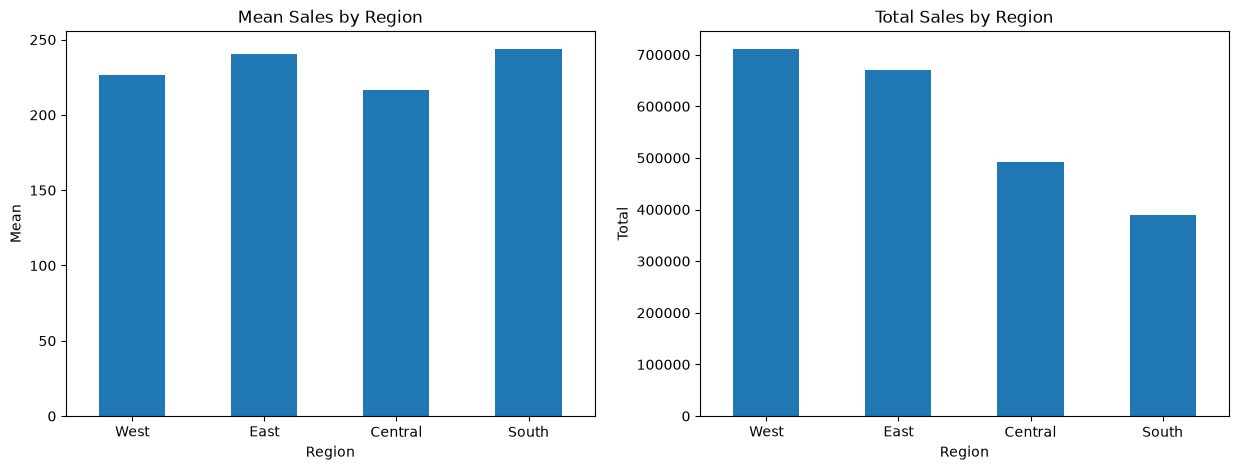

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: mean
group_region_sales_stats['mean'].plot(
    kind='bar',
    ax=axes[0]
)
axes[0].set_title('Mean Sales by Region')
axes[0].set_xlabel('Region')
axes[0].set_ylabel('Mean')
axes[0].tick_params(rotation=0)


# Gráfico 2: sum
group_region_sales_stats['sum'].plot(
    kind='bar',
    ax=axes[1]
)
axes[1].set_title('Total Sales by Region')
axes[1].set_xlabel('Region')
axes[1].set_ylabel('Total')
axes[1].tick_params(rotation=0)


plt.show()

#### 5.3.6 Category

In [79]:
df.head()

,Ship Date,Ship Mode,Segment,Country,City,State,Region,Category,Sub-Category,Sales
Order Date,,,,,,,,,,
2015-01-03,2015-01-03,Standard Class,Consumer,United States,Houston,Texas,Central,Office Supplies,Paper,16.448
2015-01-04,2015-01-04,Standard Class,Home Office,United States,Naperville,Illinois,Central,Office Supplies,Binders,3.540
2015-01-04,2015-01-04,Standard Class,Home Office,United States,Naperville,Illinois,Central,Office Supplies,Storage,272.736
2015-01-04,2015-01-04,Standard Class,Home Office,United States,Naperville,Illinois,Central,Office Supplies,Labels,11.784
2015-01-05,2015-01-05,Standard Class,Consumer,United States,Philadelphia,Pennsylvania,East,Office Supplies,Art,19.536


Grupo de Mean y Sum en Category

In [80]:
group_category_sales_stats = df.groupby('Category')['Sales'].agg(['mean', 'sum']).sort_values(by='sum', ascending=False)
group_category_sales_stats

,mean,sum
Category,,
Technology,456.401474,827455.8730
Furniture,350.653790,728658.5757
Office Supplies,119.381001,705422.3340


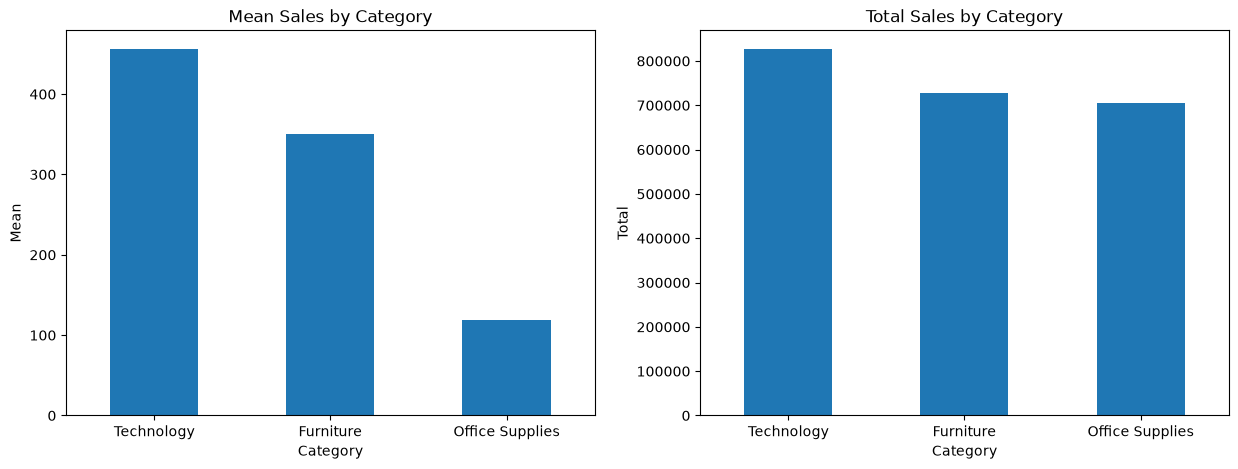

In [81]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: mean
group_category_sales_stats['mean'].plot(
    kind='bar',
    ax=axes[0]
)
axes[0].set_title('Mean Sales by Category')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Mean')
axes[0].tick_params(rotation=0)


# Gráfico 2: sum
group_category_sales_stats['sum'].plot(
    kind='bar',
    ax=axes[1]
)
axes[1].set_title('Total Sales by Category')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Total')
axes[1].tick_params(rotation=0)


plt.show()

#### 5.3.7 Sub-Category

In [82]:
df.head()

,Ship Date,Ship Mode,Segment,Country,City,State,Region,Category,Sub-Category,Sales
Order Date,,,,,,,,,,
2015-01-03,2015-01-03,Standard Class,Consumer,United States,Houston,Texas,Central,Office Supplies,Paper,16.448
2015-01-04,2015-01-04,Standard Class,Home Office,United States,Naperville,Illinois,Central,Office Supplies,Binders,3.540
2015-01-04,2015-01-04,Standard Class,Home Office,United States,Naperville,Illinois,Central,Office Supplies,Storage,272.736
2015-01-04,2015-01-04,Standard Class,Home Office,United States,Naperville,Illinois,Central,Office Supplies,Labels,11.784
2015-01-05,2015-01-05,Standard Class,Consumer,United States,Philadelphia,Pennsylvania,East,Office Supplies,Art,19.536


Grupo de Mean y Sum en Sub-Category

In [83]:
group_subcategory_sales_stats = df.groupby('Sub-Category')['Sales'].agg(['mean', 'sum']).sort_values(by='sum', ascending=False)
group_subcategory_sales_stats

,mean,sum
Sub-Category,,
Phones,374.180877,327782.4480
Chairs,531.833165,322822.7310
Storage,263.633885,219343.3920
Tables,645.893720,202810.6280
Binders,134.067550,200028.7850
Machines,1645.553313,189238.6310
Accessories,217.178175,164186.7000
Copiers,2215.880212,146248.0940
Bookcases,503.598224,113813.1987


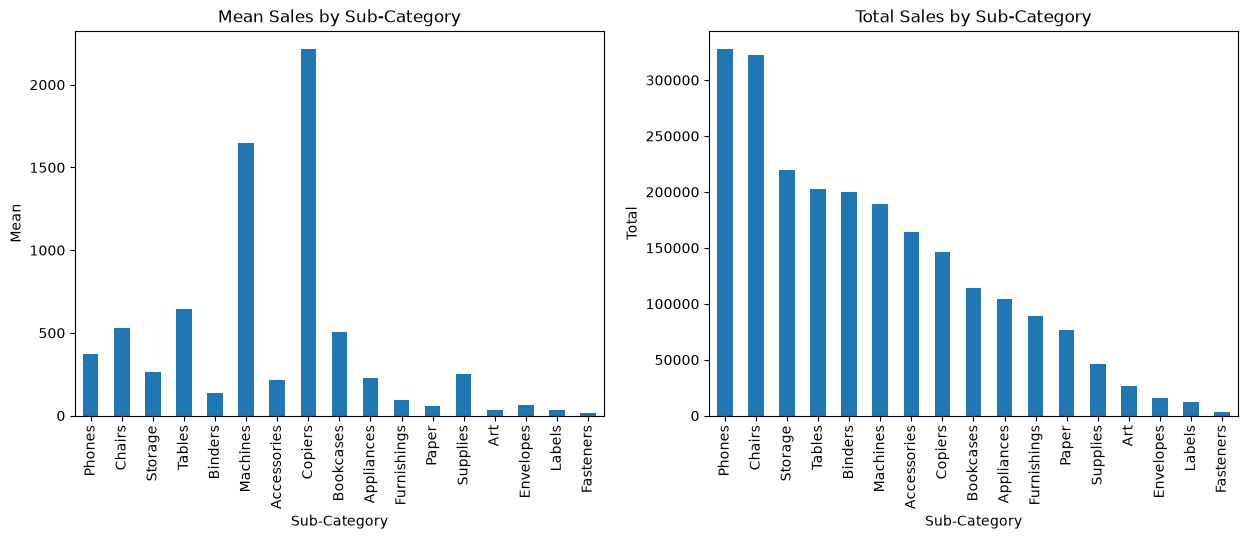

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: mean
group_subcategory_sales_stats['mean'].plot(
    kind='bar',
    ax=axes[0]
)
axes[0].set_title('Mean Sales by Sub-Category')
axes[0].set_xlabel('Sub-Category')
axes[0].set_ylabel('Mean')


# Gráfico 2: sum
group_subcategory_sales_stats['sum'].plot(
    kind='bar',
    ax=axes[1]
)
axes[1].set_title('Total Sales by Sub-Category')
axes[1].set_xlabel('Sub-Category')
axes[1].set_ylabel('Total')


plt.show()

## 6. Guardar data limpia

In [85]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 9800 entries, 2015-01-03 to 2018-12-30
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Ship Date     9800 non-null   datetime64[us]
 1   Ship Mode     9800 non-null   str           
 2   Segment       9800 non-null   str           
 3   Country       9800 non-null   str           
 4   City          9800 non-null   str           
 5   State         9800 non-null   str           
 6   Region        9800 non-null   str           
 7   Category      9800 non-null   str           
 8   Sub-Category  9800 non-null   str           
 9   Sales         9800 non-null   float64       
dtypes: datetime64[us](1), float64(1), str(8)
memory usage: 842.2 KB


In [86]:
df.to_csv('../data/clean/train_clean.csv', index=False)